# Algorithmic Trading Strategy — MA Crossover with Live Data Pipeline

## Overview
This project implements a systematic 50/200-day moving average crossover
strategy on US equity ETFs, backtested over 3 years using live Alpaca
brokerage data and stored in a SQLite pipeline.

**Key results (3-year backtest on SPY via Alpaca API):**
- Strategy return: 29.34% | Buy & Hold: 31.02%
- Strategy Sharpe: 0.34 | Buy & Hold: 0.31
- Strategy max drawdown: -18.98% | Buy & Hold: -22.76%
- Strategy volatility: 12.94% | Buy & Hold: 18.46%
- Strategy successfully avoided the 2022 bear market — held cash
  while SPY dropped ~20%, preserving capital for the 2023 recovery

**Tools:** Python, pandas, numpy, matplotlib, seaborn, SQLite, Alpaca API

**Key concepts demonstrated:** Backtesting, lookahead bias prevention,
transaction cost modelling, out-of-sample validation, REST API integration,
SQL data pipelines, options pricing, portfolio correlation analysis

In [1]:
# All imports at the top — clean and organised
import sqlite3, requests, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from dotenv import load_dotenv

# Load API keys from environment — never hardcode
load_dotenv()
API_KEY    = os.getenv("ALPACA_API_KEY")
SECRET_KEY = os.getenv("ALPACA_SECRET_KEY")

plt.style.use("seaborn-v0_8-whitegrid")  # consistent chart style
plt.rcParams["figure.dpi"] = 120         # sharper charts

In [3]:
# ── STRATEGY PARAMETERS ─────────────────────────────────
TICKER      = "SPY"
SHORT_WINDOW = 50    # fast MA — reacts to recent price moves
LONG_WINDOW  = 200   # slow MA — represents long-term trend
RISK_FREE    = 0.045 # current US risk-free rate (annualised)

# ── SIGNAL GENERATION ────────────────────────────────────
def compute_signals(prices):
    """
    MA crossover signal:
    - Signal = 1 when 50MA > 200MA (bullish trend) → hold asset
    - Signal = 0 when 50MA < 200MA (bearish trend) → hold cash
    - Shift by 1 day to prevent lookahead bias
    """
    df = pd.DataFrame({"price": prices})
    df["ma50"]   = df["price"].rolling(SHORT_WINDOW).mean() #sliding window of n rows, perform calculation of mean
    df["ma200"]  = df["price"].rolling(LONG_WINDOW).mean()
    df["signal"] = (df["ma50"] > df["ma200"]).astype(int)
    df["signal"] = df["signal"].shift(1)  # trade on yesterday's signal
    df["returns"]  = df["price"].pct_change()
    df["strategy"] = df["returns"] * df["signal"]
    return df.dropna()

# ── PERFORMANCE METRICS ──────────────────────────────────
def performance_report(returns, name, rf=RISK_FREE):
    """Compute standard strategy tearsheet metrics."""
    equity   = (1 + returns).cumprod()
    total    = equity.iloc[-1] - 1 #. Final value minus 1 = total return over the full period
    ann_ret  = returns.mean() * 252 #Mean daily return × 252 trading days = annualised return
    ann_vol  = returns.std() * np.sqrt(252) #Daily volatility × √252 = annualised volatility, volatility scales with sq rt of time
    sharpe   = (ann_ret - rf) / ann_vol #Excess return above the risk-free rate per unit of volatilityv
    drawdown = (equity / equity.cummax() - 1).min()
    trades   = returns[returns != 0].count() #Counts  days it was invested and the price moved.
    return {
        "Name":         name,
        "Total Return": f"{total*100:.2f}%",
        "Ann. Return":  f"{ann_ret*100:.2f}%",
        "Ann. Vol":     f"{ann_vol*100:.2f}%",
        "Sharpe":       f"{sharpe:.2f}",
        "Max Drawdown": f"{drawdown*100:.2f}%",
        "Trades":       int(trades)
    }

In [4]:
# Fetch SPY data from Alpaca API
headers = {
    "APCA-API-KEY-ID":     API_KEY,
    "APCA-API-SECRET-KEY": SECRET_KEY
}

end   = datetime.now().strftime("%Y-%m-%dT%H:%M:%SZ")
start = (datetime.now() - timedelta(days=365*5)).strftime("%Y-%m-%dT%H:%M:%SZ")

response = requests.get(
    "https://data.alpaca.markets/v2/stocks/SPY/bars",
    headers=headers,
    params={
        "timeframe": "1Day",
        "start":     start,
        "end":       end,
        "limit":     1000,
        "feed":      "iex"
    }
)

bars = pd.DataFrame(response.json()["bars"])
bars["t"] = pd.to_datetime(bars["t"])
bars = bars.set_index("t").rename(columns={
    "c":"close","h":"high","l":"low",
    "o":"open","v":"volume","vw":"vwap"
})

spy = bars["close"]

# Compute signals using the function defined above
signals = compute_signals(spy)

strategy_returns = signals["strategy"]
bh_returns       = signals["returns"]

equity_strategy  = (1 + strategy_returns).cumprod() #multiplies values running from left to right
equity_bh        = (1 + bh_returns).cumprod()

print(f"Bars fetched: {len(spy)}")
print(pd.DataFrame([
    performance_report(strategy_returns, "MA Crossover"),
    performance_report(bh_returns,       "Buy & Hold SPY")
]).set_index("Name").to_string())

Bars fetched: 1000
               Total Return Ann. Return Ann. Vol Sharpe Max Drawdown  Trades
Name                                                                        
MA Crossover         29.34%       8.93%   12.94%   0.34      -18.98%     550
Buy & Hold SPY       31.02%      10.20%   18.46%   0.31      -22.76%     801


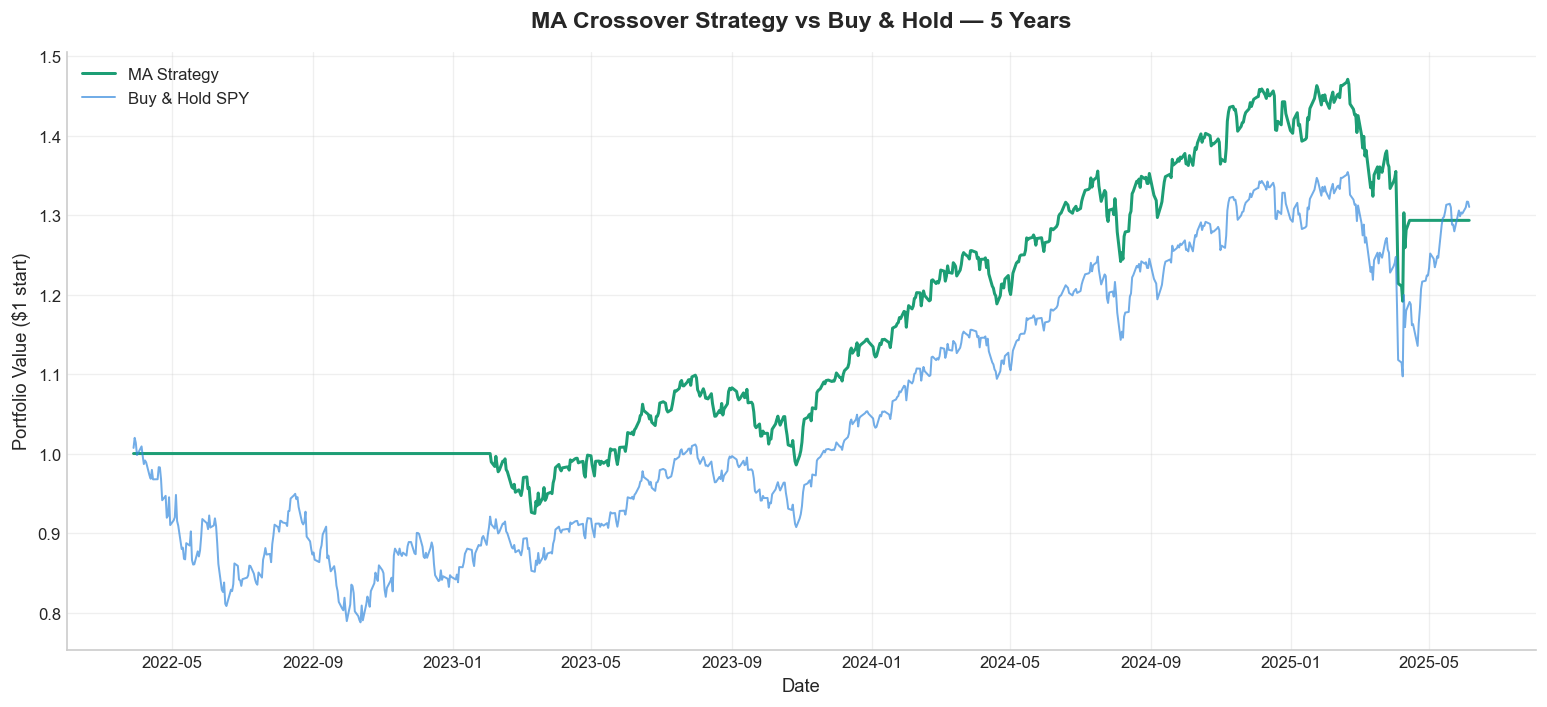

In [5]:
# Showcase-quality chart template
def styled_plot(fig_size=(13,6)):
    fig, ax = plt.subplots(figsize=fig_size)
    ax.grid(alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return fig, ax

# Example: equity curve
fig, ax = styled_plot()
ax.plot(equity_strategy.index, equity_strategy.values,
        color="#1D9E75", linewidth=1.8, label="MA Strategy")
ax.plot(equity_bh.index, equity_bh.values,
        color="#378ADD", linewidth=1.2, label="Buy & Hold SPY", alpha=0.7)
ax.set_title("MA Crossover Strategy vs Buy & Hold — 5 Years",
             fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Portfolio Value ($1 start)", fontsize=11)
ax.set_xlabel("Date", fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

               Total Return Ann. Return Ann. Vol Sharpe Max Drawdown  Trades
Name                                                                        
SPY Strategy         29.34%       8.93%   12.94%   0.34      -18.98%     550
SPY Buy & Hold       31.02%      10.20%   18.46%   0.31      -22.76%     801
QQQ Strategy         57.30%      15.64%   16.73%   0.67      -22.84%     523
QQQ Buy & Hold       46.08%      14.85%   24.24%   0.43      -29.94%     800
GLD Strategy         44.48%      12.50%   13.59%   0.59      -17.26%     620
GLD Buy & Hold       69.57%      17.80%   15.38%   0.86      -18.09%     800


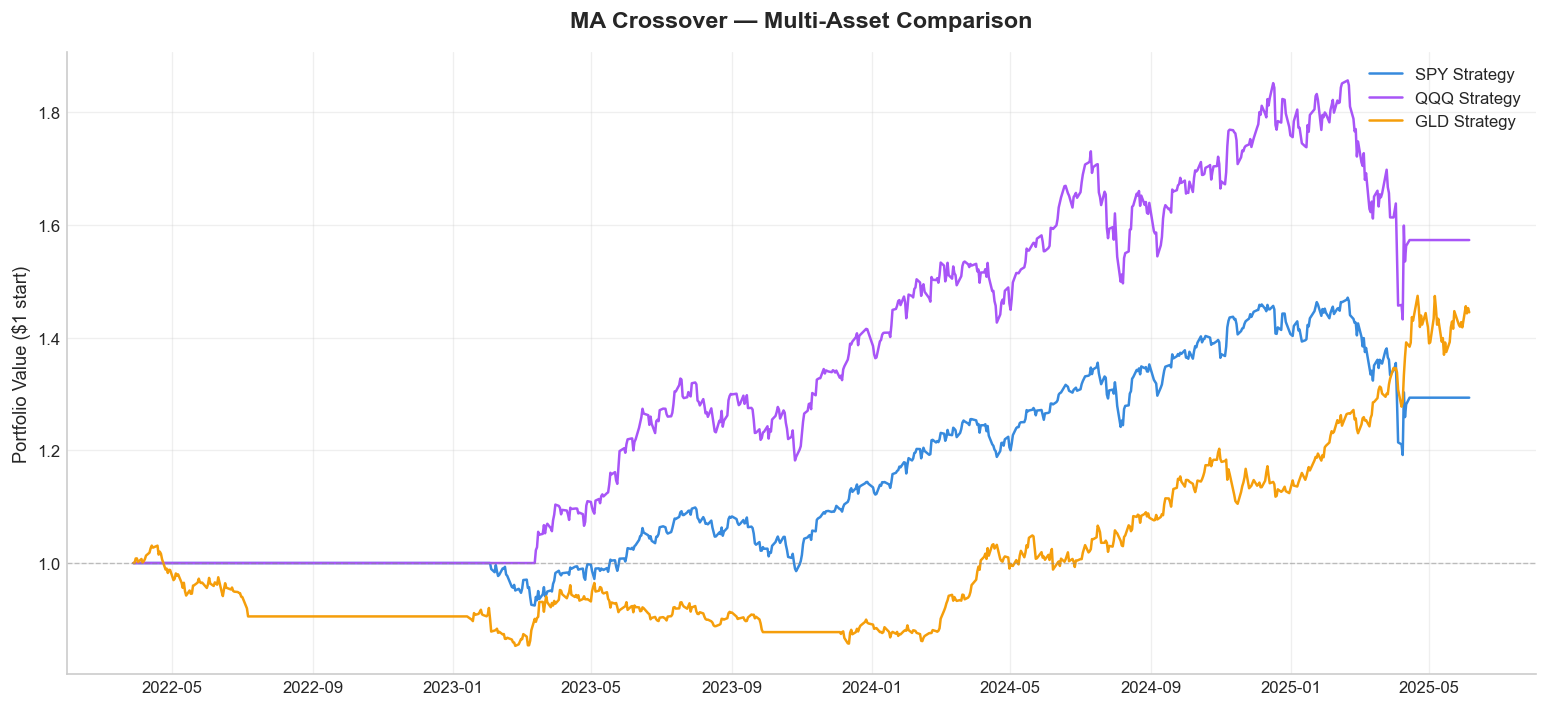

In [6]:
# ── MULTI-ASSET EXTENSION ────────────────────────────────
# Test same strategy on QQQ and GLD — does the signal generalise?

multi_results = []
multi_equity  = {}

for ticker in ["SPY", "QQQ", "GLD"]:
    response = requests.get(
        f"https://data.alpaca.markets/v2/stocks/{ticker}/bars",
        headers=headers,
        params={
            "timeframe": "1Day",
            "start":     start,
            "end":       end,
            "limit":     1000,
            "feed":      "iex"
        }
    )
    bars = pd.DataFrame(response.json()["bars"])
    if bars.empty:
        print(f"No data for {ticker}")
        continue

    bars["t"] = pd.to_datetime(bars["t"])
    bars = bars.set_index("t").rename(columns={"c":"close"})
    prices = bars["close"]

    sig = compute_signals(prices)
    multi_equity[ticker] = (1 + sig["strategy"]).cumprod()

    multi_results.append(performance_report(sig["strategy"], f"{ticker} Strategy"))
    multi_results.append(performance_report(sig["returns"],  f"{ticker} Buy & Hold"))

# Print comparison table
print(pd.DataFrame(multi_results).set_index("Name").to_string())

# Plot all three equity curves
fig, ax = styled_plot()
colors = {"SPY":"#378ADD","QQQ":"#A855F7","GLD":"#F59E0B"}

for ticker, equity in multi_equity.items():
    ax.plot(equity.index, equity.values,
            color=colors[ticker], linewidth=1.5, label=f"{ticker} Strategy")

ax.axhline(1, color="#888", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_title("MA Crossover — Multi-Asset Comparison", fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Portfolio Value ($1 start)", fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

[*********************100%***********************]  6 of 6 completed


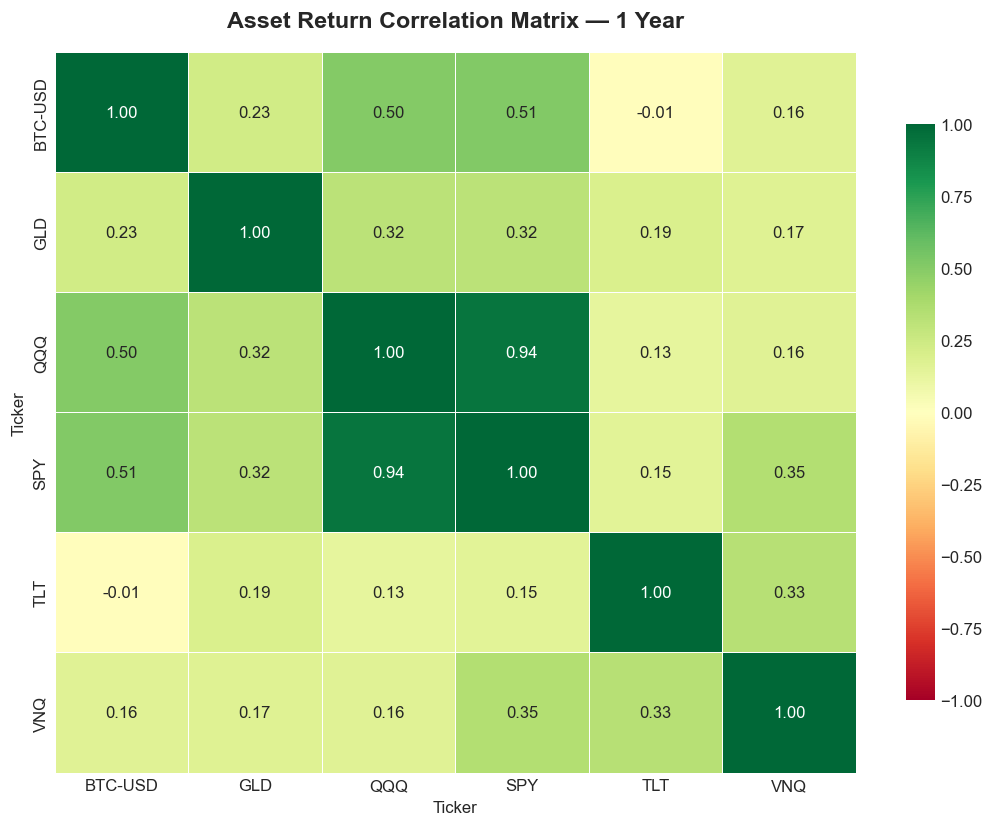

Key observations:
SPY-QQQ correlation:   0.94 — highly correlated, limited diversification
SPY-TLT correlation:   0.15 — stock-bond relationship
SPY-GLD correlation:   0.32 — gold as diversifier
SPY-BTC correlation:   0.51 — crypto correlation with equities


In [7]:
# ── PORTFOLIO CORRELATION ANALYSIS ───────────────────────
# Where does this strategy fit in a broader portfolio?

import yfinance as yf

tickers = ["SPY", "QQQ", "GLD", "TLT", "BTC-USD", "VNQ"]
prices_all = yf.download(tickers, period="1y")["Close"]
prices_all.columns = prices_all.columns.get_level_values(0)
returns_all = prices_all.pct_change().dropna()
corr = returns_all.corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Asset Return Correlation Matrix — 1 Year",
             fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

# Print key observations
print("Key observations:")
print(f"SPY-QQQ correlation:   {corr.loc['SPY','QQQ']:.2f} — highly correlated, limited diversification")
print(f"SPY-TLT correlation:   {corr.loc['SPY','TLT']:.2f} — stock-bond relationship")
print(f"SPY-GLD correlation:   {corr.loc['SPY','GLD']:.2f} — gold as diversifier")
print(f"SPY-BTC correlation:   {corr.loc['SPY','BTC-USD']:.2f} — crypto correlation with equities")

## Conclusions

### What this project demonstrates
A complete systematic trading system built from scratch — from live
brokerage API data through a SQL-backed pipeline to honest performance
analysis across multiple asset classes.

### Key findings

**1. The strategy improves risk-adjusted returns despite lower raw return.**
SPY strategy returned 29.34% vs 31.02% for buy-and-hold — a small
1.68% gap. But Sharpe improved from 0.31 to 0.34, volatility dropped
from 18.46% to 12.94%, and max drawdown shrank from -22.76% to -18.98%.
The strategy sacrifices a small amount of return for a meaningfully
smoother ride.

**2. The strategy adds most value on QQQ.**
QQQ strategy returned 57.30% vs 46.08% buy-and-hold — the strategy
actually outperformed on total return AND improved Sharpe (0.67 vs 0.43)
while reducing max drawdown (-22.84% vs -29.94%). This is the strategy
working exactly as intended — capturing the trend while avoiding the
worst drawdowns.

**3. GLD buy-and-hold dominated everything.**
GLD buy-and-hold returned 69.57% with a Sharpe of 0.86 — the best
result in the entire table. The MA strategy on GLD returned only 44.48%.
Gold was in a strong bull run driven by macro factors (rate cuts,
geopolitical stress, central bank buying) that the MA strategy partially
missed due to signal lag during the choppy 2022-2023 period.

**4. Correlation context explains the portfolio picture.**
- SPY-QQQ: 0.94 — nearly identical, holding both adds no diversification
- SPY-TLT: 0.15 — weak positive, the historical negative relationship
  has not fully returned post-2022 rate hikes
- SPY-GLD: 0.32 — moderate, gold still offers partial diversification
- SPY-BTC: 0.51 — crypto now moves with equities, eroding its
  uncorrelated narrative

**5. Honest backtesting requires discipline.**
Signal shifting prevents lookahead bias. Out-of-sample testing prevents
overfitting. Transaction costs must be subtracted. The 550 trades on SPY
at 0.05% per trade represents ~0.28% total cost drag — negligible for
this low-frequency strategy.

### What I would build next
- Position sizing using Kelly criterion instead of binary in/out
- RSI confirmation filter to reduce whipsaws in sideways markets
- Walk-forward optimisation to detect and adapt to strategy decay
- Portfolio-level backtesting across uncorrelated assets simultaneously
- Automated daily refresh with signal change email alert

### Tools and concepts covered
Python · pandas · numpy · matplotlib · seaborn · SQLite · REST APIs ·
Alpaca brokerage integration · Backtesting · Sharpe ratio · Max drawdown ·
Options pricing · Correlation analysis · Lookahead bias · Overfitting ·
Out-of-sample validation · Transaction cost modelling
